In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder


data = pd.read_csv(r'C:\Users\Lenovo\student-performance\data\student_data.csv')
X_train = np.load(r'C:\Users\Lenovo\student-performance\data\X_train.npy')
X_test = np.load(r'C:\Users\Lenovo\student-performance\data\X_test.npy')
y_train = np.load(r'C:\Users\Lenovo\student-performance\data\y_train.npy')
y_test = np.load(r'C:\Users\Lenovo\student-performance\data\y_test.npy')

lr_model = LogisticRegression(random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
dt_model = DecisionTreeClassifier(random_state=42)

lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)

print('Everything is loaded')
print(f'Dataset Shape: {data.shape}')

Everything is loaded
Dataset Shape: (300, 9)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_1956\2819072880.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance, y=feature_names, palette='viridis')


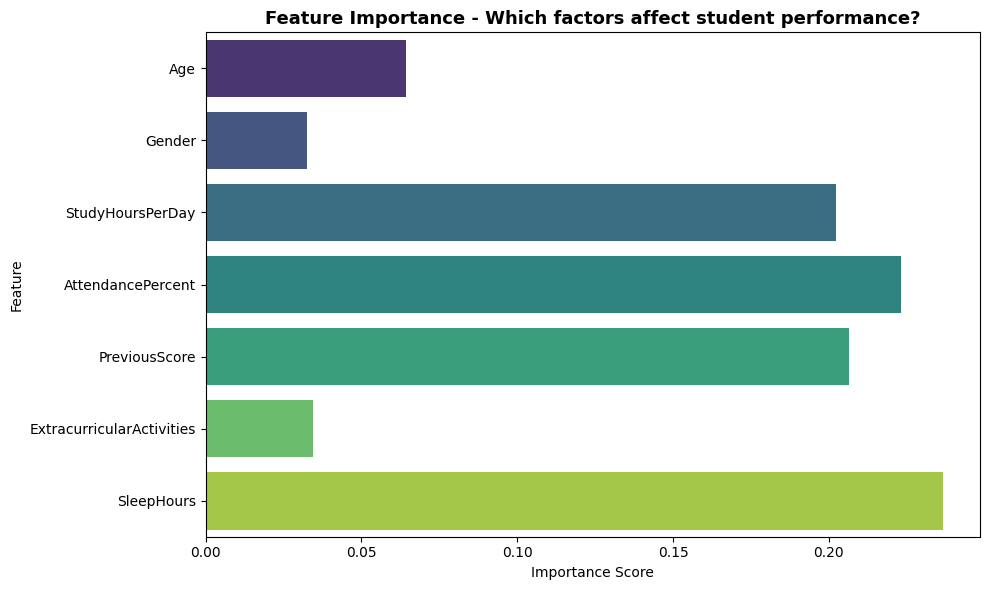


factors affecting student performance:
SleepHours: 0.2367
AttendancePercent: 0.2233
PreviousScore: 0.2065
StudyHoursPerDay: 0.2022
Age: 0.0643
ExtracurricularActivities: 0.0345
Gender: 0.0326


In [4]:

feature_names = ['Age', 'Gender', 'StudyHoursPerDay', 
                 'AttendancePercent', 'PreviousScore',
                 'ExtracurricularActivities', 'SleepHours']

importance = rf_model.feature_importances_

plt.figure(figsize=(10, 6))
sns.barplot(x=importance, y=feature_names, palette='viridis')
plt.title('Feature Importance - Which factors affect student performance?', 
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print('\nfactors affecting student performance:')
for name, imp in sorted(zip(feature_names, importance), 
                        key=lambda x: x[1], reverse=True):
    print(f'{name}: {imp:.4f}')

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_1956\3980674208.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='FinalResult', data=data, palette='viridis', ax=axes[0,0])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_1956\3980674208.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='FinalResult', y='StudyHoursPerDay',
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_1956\3980674208.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='FinalResult', y='AttendancePercent',
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_1956\3980674208.py:

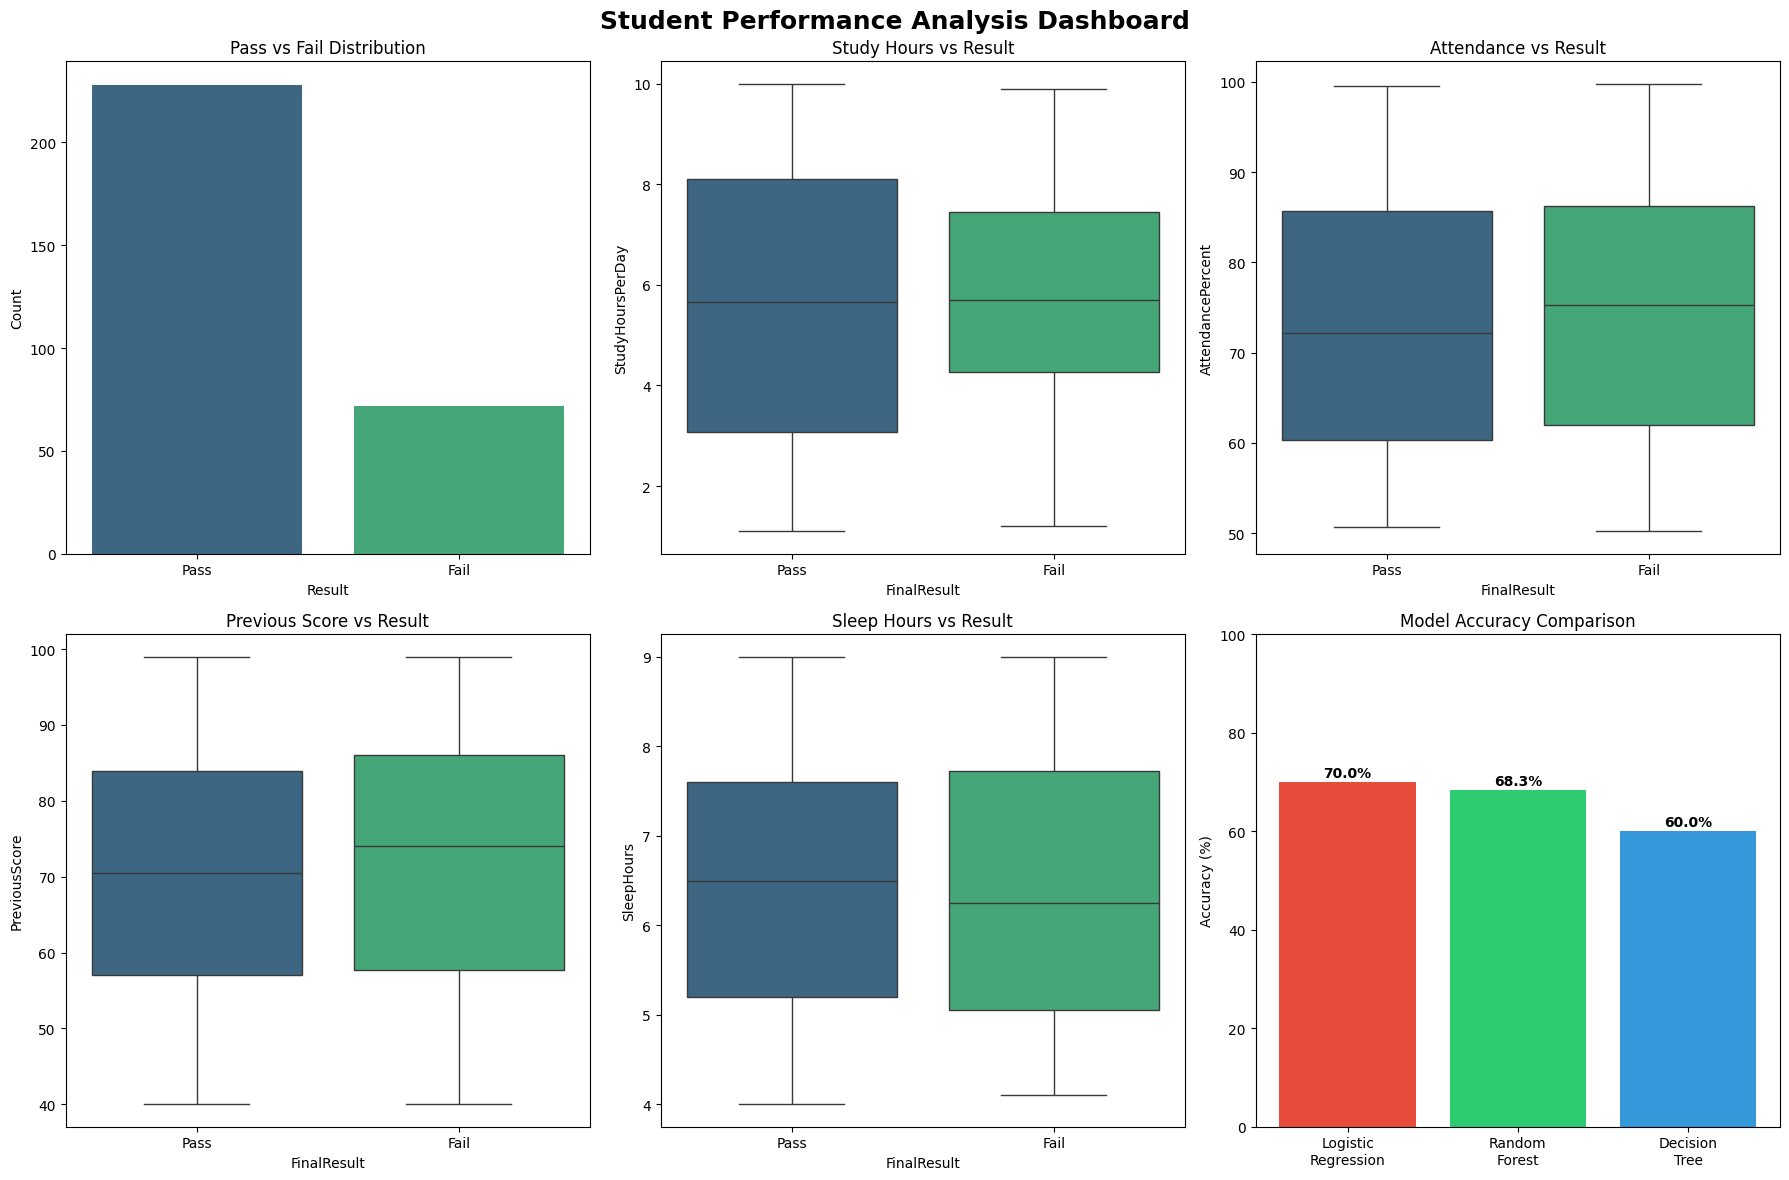

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Student Performance Analysis Dashboard', 
             fontsize=18, fontweight='bold')

# 1. Pass vs Fail
sns.countplot(x='FinalResult', data=data, palette='viridis', ax=axes[0,0])
axes[0,0].set_title('Pass vs Fail Distribution')
axes[0,0].set_xlabel('Result')
axes[0,0].set_ylabel('Count')

sns.boxplot(x='FinalResult', y='StudyHoursPerDay', 
            data=data, palette='viridis', ax=axes[0,1])
axes[0,1].set_title('Study Hours vs Result')
sns.boxplot(x='FinalResult', y='AttendancePercent', 
            data=data, palette='viridis', ax=axes[0,2])
axes[0,2].set_title('Attendance vs Result')

# 4. Previous Score vs Result
sns.boxplot(x='FinalResult', y='PreviousScore', 
            data=data, palette='viridis', ax=axes[1,0])
axes[1,0].set_title('Previous Score vs Result')

# 5. Sleep Hours vs Result
sns.boxplot(x='FinalResult', y='SleepHours', 
            data=data, palette='viridis', ax=axes[1,1])
axes[1,1].set_title('Sleep Hours vs Result')

# 6. Model Accuracy Comparison
models = ['Logistic\nRegression', 'Random\nForest', 'Decision\nTree']
accuracies = [
    accuracy_score(y_test, lr_model.predict(X_test))*100,
    accuracy_score(y_test, rf_model.predict(X_test))*100,
    accuracy_score(y_test, dt_model.predict(X_test))*100
]
bars = axes[1,2].bar(models, accuracies, color=['#e74c3c', '#2ecc71', '#3498db'])
axes[1,2].set_title('Model Accuracy Comparison')
axes[1,2].set_ylabel('Accuracy (%)')
axes[1,2].set_ylim(0, 100)
for bar, acc in zip(bars, accuracies):
    axes[1,2].text(bar.get_x() + bar.get_width()/2, 
                   bar.get_height() + 1,
                   f'{acc:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [9]:

print('STUDENT PERFORMANCE ANALYSIS')
print('\nDataset Summary:')
print(f'Total Students: {len(data)}')
print(f'Pass Rate: {(data["FinalResult"]=="Pass").sum()/len(data)*100:.1f}%')
print(f'Fail Rate: {(data["FinalResult"]=="Fail").sum()/len(data)*100:.1f}%')

print('\nStudy Hours:')
print(f'Average study hours (Pass): {data[data["FinalResult"]=="Pass"]["StudyHoursPerDay"].mean():.1f} hrs/day')
print(f'Average study hours (Fail): {data[data["FinalResult"]=="Fail"]["StudyHoursPerDay"].mean():.1f} hrs/day')

print('\nAttendance:')
print(f'Average attendance (Pass): {data[data["FinalResult"]=="Pass"]["AttendancePercent"].mean():.1f}%')
print(f'Average attendance (Fail): {data[data["FinalResult"]=="Fail"]["AttendancePercent"].mean():.1f}%')

print('\nBest Model:')
best_acc = max(accuracies)
best_model = models[accuracies.index(best_acc)]
print(f'Best Model: {best_model.replace(chr(10), " ")}')
print(f'Best Accuracy: {best_acc:.2f}%')

print('\n Recommendations:')
print('1 Students studying less than 5hrs/day need attention')
print('2 Attendance below 70% strongly linked to failure')
print('3 Previous score is the strongest predictor of success')

STUDENT PERFORMANCE ANALYSIS

Dataset Summary:
Total Students: 300
Pass Rate: 76.0%
Fail Rate: 24.0%

Study Hours:
Average study hours (Pass): 5.6 hrs/day
Average study hours (Fail): 5.7 hrs/day

Attendance:
Average attendance (Pass): 73.4%
Average attendance (Fail): 74.1%

Best Model:
Best Model: Logistic Regression
Best Accuracy: 70.00%

 Recommendations:
1 Students studying less than 5hrs/day need attention
2 Attendance below 70% strongly linked to failure
3 Previous score is the strongest predictor of success
